# Lab 1 — Dynamic Model of a Multi-Link Manipulator  
## Course: Robot Motion Planning and Control
 **Stanford manipulator** is used as the selected robot model from the Robotics Toolbox.  

1. Load the manipulator and print its Denavit–Hartenberg parameters  
2. Print the dynamic parameters of each link  
3. Specify and display initial and final configurations  
4. Plan a trajectory  
5. Solve inverse dynamics with the Newton–Euler method for three required scenarios  
6. Compute \(M(q)\), \(C(q, \dot q)\), and \(G(q)\) at every time step  
7. Plot torque graphs for each scenario  
8. Summarize the results


## Step 0. Import the libraries

We import the packages required for:
- numerical calculations
- tabular display
- manipulator modeling
- trajectory generation
- plotting


In [2]:
import numpy as np
import pandas as pd
import roboticstoolbox as rtb
import matplotlib.pyplot as plt


## Step 1. Load the manipulator model from the toolbox

We load the **Stanford manipulator** from the Robotics Toolbox.  
Then we print the full robot model so we can verify that the robot has been loaded correctly.


In [3]:
robot = rtb.models.DH.Stanford()
print(robot)
print(f"Number of joints: {robot.n}")


DHRobot: Stanford arm (by Victor Scheinman), 6 joints (RRPRRR), dynamics, standard DH parameters
┌────────┬───────┬────────┬────────┬─────────────────────┬────────┐
│   θⱼ   │  dⱼ   │   aⱼ   │   ⍺ⱼ   │         q⁻          │   q⁺   │
├────────┼───────┼────────┼────────┼─────────────────────┼────────┤
│  q1    │ 0.412 │      0 │ -90.0° │             -170.0° │ 170.0° │
│  q2    │ 0.154 │      0 │  90.0° │             -170.0° │ 170.0° │
│ -90.0° │    q3 │ 0.0203 │   0.0° │ 0.30479999999999996 │   1.27 │
│  q4    │     0 │      0 │ -90.0° │             -170.0° │ 170.0° │
│  q5    │     0 │      0 │  90.0° │              -90.0° │  90.0° │
│  q6    │     0 │      0 │   0.0° │             -170.0° │ 170.0° │
└────────┴───────┴────────┴────────┴─────────────────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬─────┬─────┬────┬─────┬─────┬─────┐
│ name │ q0  │ q1  │ q2 │ q3  │ q4  │ q5  │
├──────┼─────┼─────┼────┼─────┼─────┼─────┤
│   qr │  0° │  0° │  0 │  0° │  0° │  0° │
│   qz │  0° │  0° │  0 │  0°

## Step 2. Output the Denavit–Hartenberg parameters

We extract the main DH-related parameters from each link:
- joint type
- \(d\)
- \(a\)
- \(\alpha\)
- offset
- joint limits

This gives the DH table


In [4]:
dh_rows = []
# DH-related parameters
for i, link in enumerate(robot.links, start=1):
    joint_type = "P" if getattr(link, "sigma", 0) == 1 else "R"
    dh_rows.append({
        "Link": i,
        "Joint type": joint_type,
        "d": getattr(link, "d", None),
        "a": getattr(link, "a", None),
        "alpha (rad)": getattr(link, "alpha", None),
        "offset": getattr(link, "offset", None),
        "qlim": getattr(link, "qlim", None),
    })

dh_df = pd.DataFrame(dh_rows)
dh_df


,Link,Joint type,d,a,alpha (rad),offset,qlim
0,1,R,0.412,0.0000,-1.570796,0.0,"[-2.9670597283903604, 2.9670597283903604]"
1,2,R,0.154,0.0000,1.570796,0.0,"[-2.9670597283903604, 2.9670597283903604]"
2,3,P,0.000,0.0203,0.000000,0.0,"[0.30479999999999996, 1.27]"
3,4,R,0.000,0.0000,-1.570796,0.0,"[-2.9670597283903604, 2.9670597283903604]"
4,5,R,0.000,0.0000,1.570796,0.0,"[-1.5707963267948966, 1.5707963267948966]"
5,6,R,0.000,0.0000,0.000000,0.0,"[-2.9670597283903604, 2.9670597283903604]"


## Step 3. Output the dynamic parameters of each link

We create a table containing the required dynamic data:
- mass \(m\)
- center of mass \(r\)
- inertia tensor \(I\)
- motor inertia \(J_m\)
- viscous friction \(B\)
- Coulomb friction \(T_c\)
- gear ratio \(G\)
- joint limits \(q_{lim}\)




In [5]:
dyn_rows = []
#
for i, link in enumerate(robot.links, start=1):
    dyn_rows.append({
        "Link": i,
        "m (kg)": getattr(link, "m", None),
        "r (m)": getattr(link, "r", None),
        "I": getattr(link, "I", None),
        "Jm": getattr(link, "Jm", None),
        "B": getattr(link, "B", None),
        "Tc": getattr(link, "Tc", None),
        "G": getattr(link, "G", None),
        "qlim": getattr(link, "qlim", None),
    })

dyn_df = pd.DataFrame(dyn_rows)
dyn_df


,Link,m (kg),r (m),I,Jm,B,Tc,G,qlim
0,1,9.29,"[0.0, 0.0175, -0.1105]","[[0.276, 0.0, 0.0], [0.0, 0.255, 0.0], [0.0, 0...",0.953,0.0,"[0.0, 0.0]",1,"[-2.9670597283903604, 2.9670597283903604]"
1,2,5.01,"[0.0, -1.054, 0.0]","[[0.108, 0.0, 0.0], [0.0, 0.018, 0.0], [0.0, 0...",2.193,0.0,"[0.0, 0.0]",1,"[-2.9670597283903604, 2.9670597283903604]"
2,3,4.25,"[0.0, 0.0, -6.447]","[[2.51, 0.0, 0.0], [0.0, 2.51, 0.0], [0.0, 0.0...",0.782,0.0,"[0.0, 0.0]",1,"[0.30479999999999996, 1.27]"
3,4,1.08,"[0.0, 0.092, -0.054]","[[0.002, 0.0, 0.0], [0.0, 0.001, 0.0], [0.0, 0...",0.106,0.0,"[0.0, 0.0]",1,"[-2.9670597283903604, 2.9670597283903604]"
4,5,0.63,"[0.0, 0.566, 0.003]","[[0.003, 0.0, 0.0], [0.0, 0.0004, 0.0], [0.0, ...",0.097,0.0,"[0.0, 0.0]",1,"[-1.5707963267948966, 1.5707963267948966]"
5,6,0.51,"[0.0, 0.0, 1.554]","[[0.013, 0.0, 0.0], [0.0, 0.013, 0.0], [0.0, 0...",0.020,0.0,"[0.0, 0.0]",1,"[-2.9670597283903604, 2.9670597283903604]"


## Step 4. Specify arbitrary initial and final configurations

We choose an arbitrary start configuration and an arbitrary final configuration.  
The third joint of the Stanford manipulator is prismatic, so its value is given in **meters**, while the other joints are in **radians**.


In [6]:
q_start = np.array([0.0, 0.0, 0.20, 0.0, 0.0, 0.0])
q_end   = np.array([np.pi/2, np.pi/4, 0.40, np.pi/3, -np.pi/4, np.pi/2])

print("Initial configuration q_start:")
print(q_start)

print("\nFinal configuration q_end:")
print(q_end)


Initial configuration q_start:
[0.  0.  0.2 0.  0.  0. ]

Final configuration q_end:
[ 1.57079633  0.78539816  0.4         1.04719755 -0.78539816  1.57079633]


## Step 5. Display the initial and final configurations

We visualize the robot in:
- the initial configuration
- the final configuration

This satisfies the requirement to specify and display the configurations.


Displaying the initial configuration...


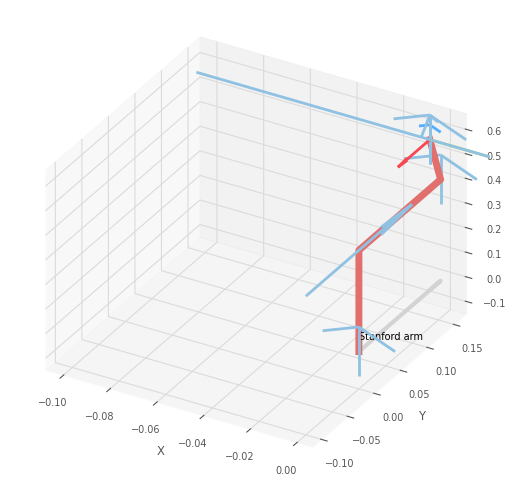

Displaying the final configuration...


<Figure size 640x480 with 0 Axes>

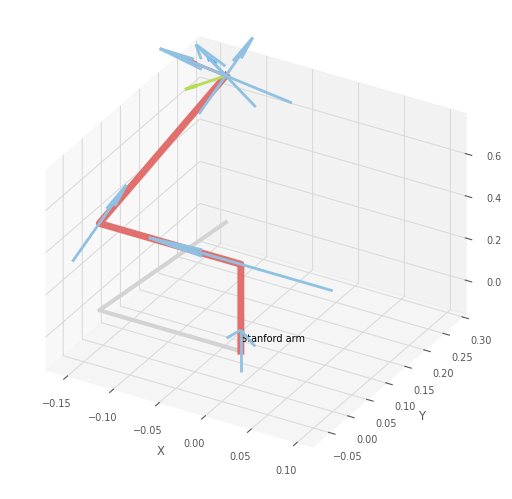

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'Stanford arm')

<Figure size 640x480 with 0 Axes>

In [7]:
print("Displaying the initial configuration...")
robot.plot(q_start)

print("Displaying the final configuration...")
robot.plot(q_end)


## Step 6. Plan a trajectory between the specified configurations

We generate a smooth joint-space trajectory using `jtraj()`.  
This function returns:
- desired positions \(q(t)\)
- desired velocities \(\dot q(t)\)
- desired accelerations \(\ddot q(t)\)



In [8]:
t_start = 0.0
t_stop = 5.0
steps = 100

t = np.linspace(t_start, t_stop, steps)
traj = rtb.jtraj(q_start, q_end, t)

print("Trajectory shapes:")
print("q   :", traj.q.shape)
print("qd  :", traj.qd.shape)
print("qdd :", traj.qdd.shape)


Trajectory shapes:
q   : (100, 6)
qd  : (100, 6)
qdd : (100, 6)


## Step 7. Solve inverse dynamics for the dynamic case

We compute the actuator torques/forces for the first required scenario:

\[
\dot q \neq 0, \qquad \ddot q \neq 0
\]

This is the standard dynamic case along the planned trajectory.


In [9]:
tau_dynamic = np.array([
    robot.rne(q, qd, qdd)
    for q, qd, qdd in zip(traj.q, traj.qd, traj.qdd)
])

print("tau_dynamic shape:", tau_dynamic.shape)
tau_dynamic[:5]


tau_dynamic shape: (100, 6)


array([[ 2.46519033e-32, -2.92593060e+00,  6.34707000e+01,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 2.82340958e-01,  3.83958701e-01,  6.34993001e+01,
         1.53381145e-02, -2.47878026e-02,  7.68222004e-04],
       [ 5.47400143e-01,  3.50289730e+00,  6.35262173e+01,
         2.97354646e-02, -4.77064685e-02,  1.48941149e-03],
       [ 7.95546386e-01,  6.44583046e+00,  6.35516476e+01,
         4.32077783e-02, -6.84840020e-02,  2.16454169e-03],
       [ 1.02716417e+00,  9.22686590e+00,  6.35758650e+01,
         5.57699971e-02, -8.68917032e-02,  2.79458752e-03]])

## Step 8. Solve inverse dynamics for the quasi-static case

We compute the actuator torques/forces for the second required scenario:

\[
\dot q \neq 0, \qquad \ddot q \approx 0
\]

To model quasi-statics, we keep the same joint velocities but set accelerations to zero.


In [10]:
qdd_quasi = np.zeros_like(traj.qdd)

tau_quasi = np.array([
    robot.rne(q, qd, qdd0)
    for q, qd, qdd0 in zip(traj.q, traj.qd, qdd_quasi)
])

print("tau_quasi shape:", tau_quasi.shape)
tau_quasi[:5]


tau_quasi shape: (100, 6)


array([[ 2.46519033e-32, -2.92593060e+00,  6.34707000e+01,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.90565474e-07, -2.92394840e+00,  6.34707055e+01,
         2.35182137e-08,  6.09761481e-05,  6.65898135e-11],
       [ 3.05446883e-06, -2.91035241e+00,  6.34707838e+01,
         3.97337495e-07,  4.71733830e-04,  1.02231183e-09],
       [ 1.64894601e-05, -2.87428131e+00,  6.34711062e+01,
         2.23406873e-06,  1.54027537e-03,  4.96144584e-09],
       [ 5.95413916e-05, -2.80566723e+00,  6.34719277e+01,
         8.11060555e-06,  3.53353449e-03,  1.50150582e-08]])

## Step 9. Solve inverse dynamics for the static holding case

We compute the actuator torques/forces for the third required scenario:

\[
\dot q = 0, \qquad \ddot q = 0
\]

This corresponds to maintaining a given position.  
We evaluate this case at each position along the same trajectory, but with zero velocities and zero accelerations.


In [11]:
qd_static = np.zeros_like(traj.qd)
qdd_static = np.zeros_like(traj.qdd)

tau_static = np.array([
    robot.rne(q, qd0, qdd0)
    for q, qd0, qdd0 in zip(traj.q, qd_static, qdd_static)
])

print("tau_static shape:", tau_static.shape)
tau_static[:5]


tau_static shape: (100, 6)


array([[ 2.46519033e-32, -2.92593060e+00,  6.34707000e+01,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 7.03094479e-20, -2.92394329e+00,  6.34707000e+01,
         7.43270276e-10,  6.21299123e-05,  0.00000000e+00],
       [ 9.07328802e-19, -2.91027372e+00,  6.34706999e+01,
         4.61344445e-08,  4.89449907e-04,  0.00000000e+00],
       [-7.68395829e-19, -2.87389747e+00,  6.34706986e+01,
         5.09537177e-07,  1.62629386e-03,  0.00000000e+00],
       [-1.72284902e-18, -2.80449432e+00,  6.34706925e+01,
         2.77532906e-06,  3.79408464e-03,  0.00000000e+00]])

## Step 10. Determine the matrices \(M(q)\), \(C(q, \dot q)\), and \(G(q)\)

We compute the required dynamic terms at every time step:
- inertia matrix \(M(q)\)
- Coriolis/centrifugal matrix \(C(q, \dot q)\)
- gravity load vector \(G(q)\)

These values are stored as arrays for later analysis.


In [12]:
M_list = []
C_list = []
G_list = []

for q, qd in zip(traj.q, traj.qd):
    M_list.append(robot.inertia(q))
    C_list.append(robot.coriolis(q, qd))
    G_list.append(robot.gravload(q))

M = np.array(M_list)
C = np.array(C_list)
G = np.array(G_list)

print("Shapes of dynamic terms:")
print("M:", M.shape)   # (steps, n, n)
print("C:", C.shape)   # (steps, n, n)
print("G:", G.shape)   # (steps, n)


Shapes of dynamic terms:
M: (100, 6, 6)
C: (100, 6, 6)
G: (100, 6)


## Step 11. Show sample numerical values of \(M\), \(C\), and \(G\)

We print the values of the dynamic terms at the first time instant.  
This demonstrates that the matrices__vectors have been computed numerically.


In [13]:
print("M(q) at the first time step:")
print(M[0])

print("\nC(q, qd) at the first time step:")
print(C[0])

print("\nG(q) at the first time step:")
print(G[0])


M(q) at the first time step:
[[ 5.80746250e+00  3.39740792e+00 -3.08148791e-33  2.06273560e-01
  -1.06974000e-03  3.00000000e-04]
 [ 3.39740792e+00  1.72407844e+02 -2.98260000e-01  8.58394008e-18
   8.58985077e-17  1.83697020e-20]
 [ 0.00000000e+00 -2.98260000e-01  7.25200000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 2.06273560e-01  8.58394008e-18  0.00000000e+00  3.12273560e-01
  -1.06974000e-03  3.00000000e-04]
 [-1.06974000e-03  8.58985077e-17  0.00000000e+00 -1.06974000e-03
   1.34201283e+00  1.83697020e-20]
 [ 3.00000000e-04  1.83697020e-20  0.00000000e+00  3.00000000e-04
   1.83697020e-20  2.03000000e-02]]

C(q, qd) at the first time step:
[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]

G(q) at the first time step:
[ 2.46519033e-32 -2.92593060e+00  6.34707000e+01  0.00000000e+00
  0.00000000e+00  0.00000000e+00]


## Step 12. Plot the torques for the dynamic case

Here We plot the actuator torques/forces along the trajectory for the dynamic case:
\[
\dot q \neq 0, \quad \ddot q \neq 0
\]


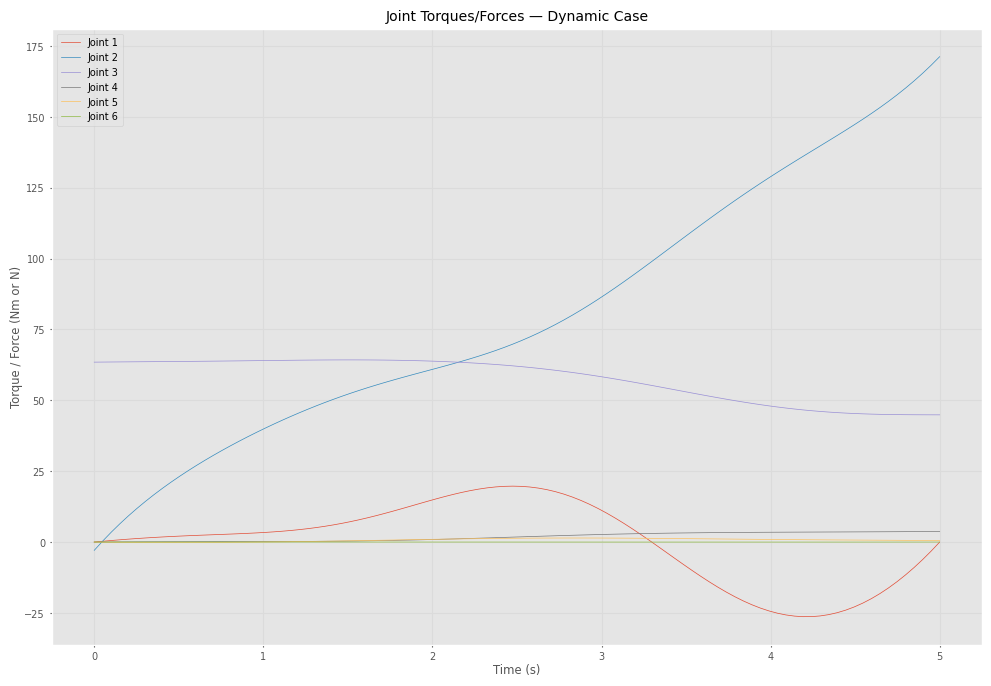

In [14]:
plt.figure(figsize=(12, 8))
for j in range(robot.n):
    plt.plot(t, tau_dynamic[:, j], label=f"Joint {j+1}")

plt.title("Joint Torques/Forces — Dynamic Case")
plt.xlabel("Time (s)")
plt.ylabel("Torque / Force (Nm or N)")
plt.grid(True)
plt.legend()
plt.show()


## Step 13. Plot the torques for the quasi-static case

and now we plot the actuator torques/forces for the quasi-static case:
\[
\dot q \neq 0, \quad \ddot q \approx 0
\]


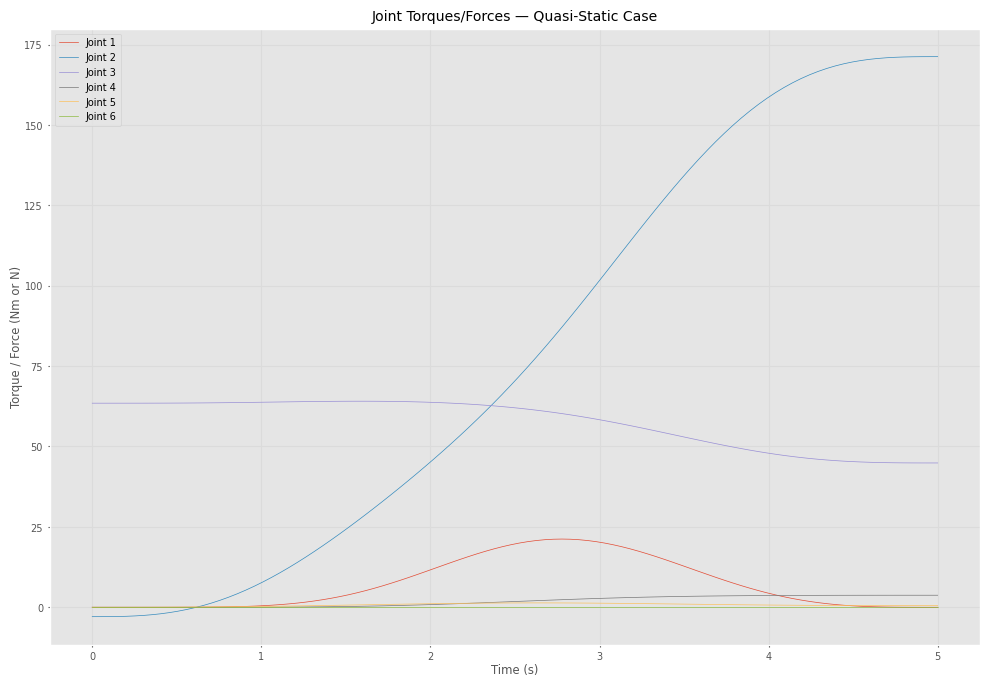

In [15]:
plt.figure(figsize=(12, 8))
for j in range(robot.n):
    plt.plot(t, tau_quasi[:, j], label=f"Joint {j+1}")

plt.title("Joint Torques/Forces — Quasi-Static Case")
plt.xlabel("Time (s)")
plt.ylabel("Torque / Force (Nm or N)")
plt.grid(True)
plt.legend()
plt.show()


## Step 14. Plot the torques for the static holding case

We plot the actuator torques/forces for the static case:
\[
\dot q = 0, \quad \ddot q = 0
\]


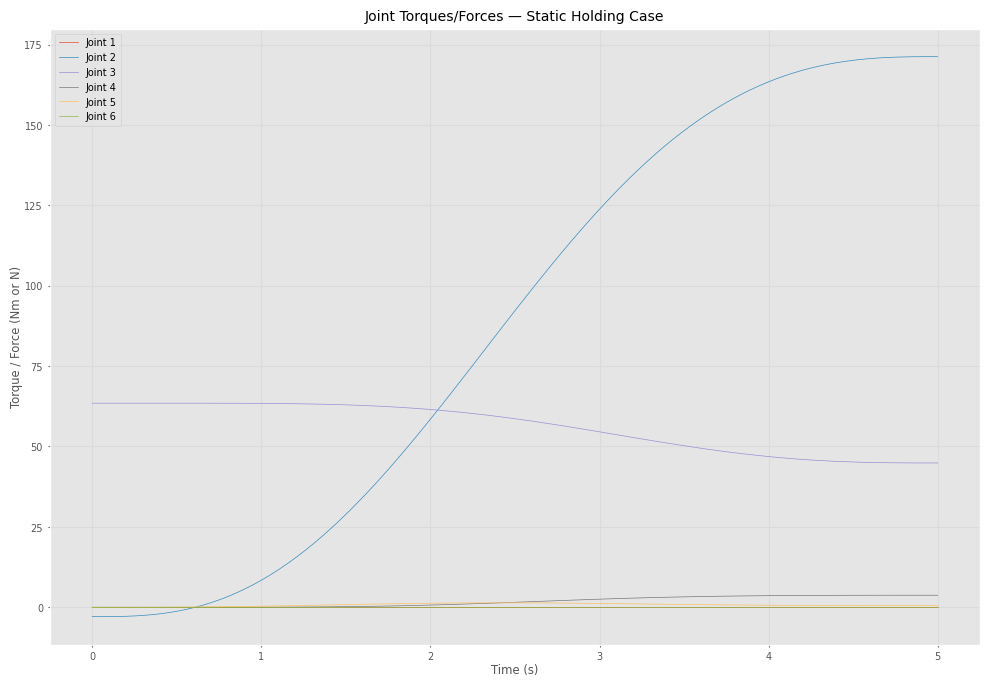

In [16]:
plt.figure(figsize=(12, 8))
for j in range(robot.n):
    plt.plot(t, tau_static[:, j], label=f"Joint {j+1}")

plt.title("Joint Torques/Forces — Static Holding Case")
plt.xlabel("Time (s)")
plt.ylabel("Torque / Force (Nm or N)")
plt.grid(True)
plt.legend()
plt.show()


## Step 15. Compare the three scenarios on one figure

this we compare the torque/force history of each joint for all three previous cases.  
This makes it easier to see how dynamic, quasi-static, and static conditions differ.


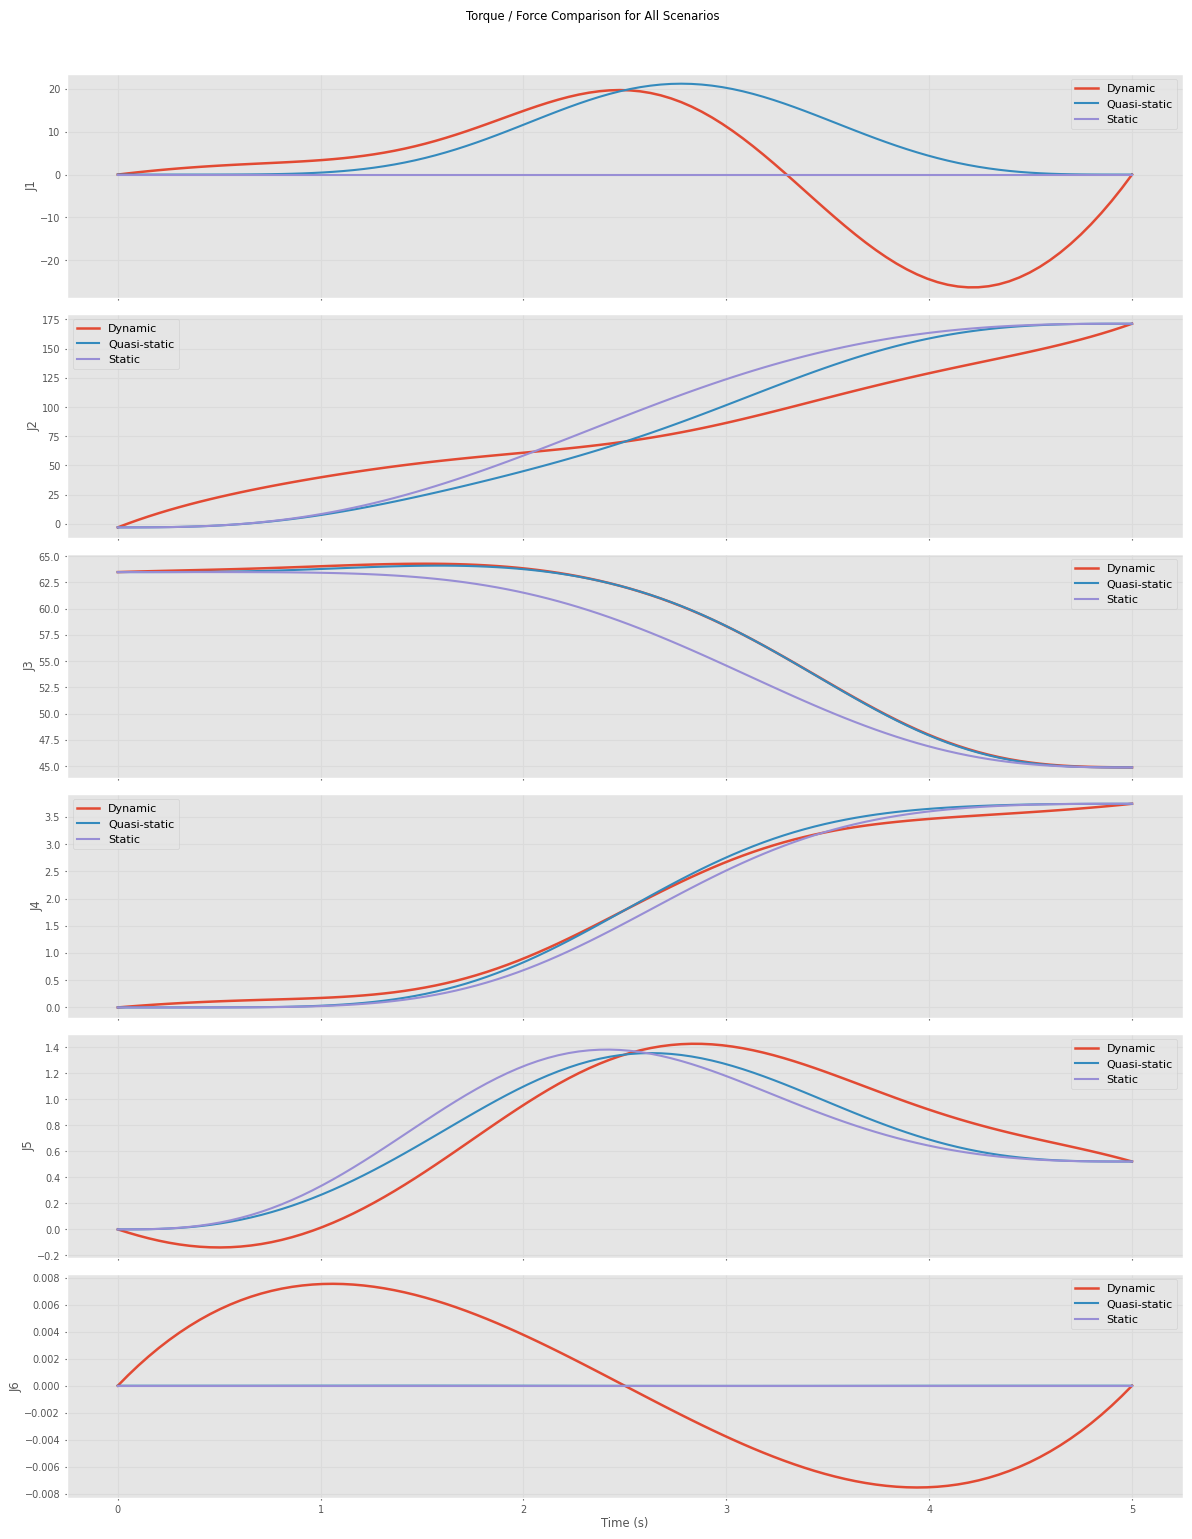

In [17]:
fig, axes = plt.subplots(robot.n, 1, figsize=(12, 2.5 * robot.n), sharex=True)

for j in range(robot.n):
    axes[j].plot(t, tau_dynamic[:, j], label="Dynamic", linewidth=1.8)
    axes[j].plot(t, tau_quasi[:, j], label="Quasi-static", linewidth=1.5)
    axes[j].plot(t, tau_static[:, j], label="Static", linewidth=1.5)
    axes[j].set_ylabel(f"J{j+1}")
    axes[j].grid(True)
    axes[j].legend(loc="best", fontsize=8)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Torque / Force Comparison for All Scenarios", y=1.02)
plt.tight_layout()
plt.show()


## Step 16. Save selected numerical results if needed

We create DataFrames containing selected numerical results.  



In [18]:
tau_dynamic_df = pd.DataFrame(tau_dynamic, columns=[f"Joint_{i+1}" for i in range(robot.n)])
tau_quasi_df   = pd.DataFrame(tau_quasi,   columns=[f"Joint_{i+1}" for i in range(robot.n)])
tau_static_df  = pd.DataFrame(tau_static,  columns=[f"Joint_{i+1}" for i in range(robot.n)])

tau_dynamic_df.head()


,Joint_1,Joint_2,Joint_3,Joint_4,Joint_5,Joint_6
0,2.465190e-32,-2.925931,63.470700,0.000000,0.000000,0.000000
1,2.823410e-01,0.383959,63.499300,0.015338,-0.024788,0.000768
2,5.474001e-01,3.502897,63.526217,0.029735,-0.047706,0.001489
3,7.955464e-01,6.445830,63.551648,0.043208,-0.068484,0.002165
4,1.027164e+00,9.226866,63.575865,0.055770,-0.086892,0.002795


## Step 17. Conclusions


- A manipulator model different from Puma560 was loaded from the toolbox.
- The Denavit–Hartenberg parameters were displayed.
- The dynamic parameters of each link were listed.
- Arbitrary initial and final configurations were selected and displayed.
- A trajectory was planned between them.
- The inverse dynamics problem was solved using the Newton–Euler method for:
  1. the dynamic case,
  2. the quasi-static case,
  3. the static holding case.
- The numerical values of \(M(q)\), \(C(q, \dot q)\), and \(G(q)\) were computed at each time step.
- Torque/force plots were created for each required scenario.

